# PowerFactory Simulation - Getting Started

This notebook demonstrates how to generate transient stability datasets using either:
- **Mock Engine**: Synthetic data generation (no PowerFactory required)
- **PowerFactory Engine**: Real simulation with DIgSILENT PowerFactory

Simply change `simulation_engine='mock'` to `simulation_engine='powerfactory'` to switch!

## 1. Setup

Import required modules:

In [2]:
from tranpy.simulation import (
    PowerSystemSimulator,
    generate_dataset_from_simulation,
    configure_powerfactory_path  # Only needed for PowerFactory engine
)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
%matplotlib inline

## 2. Configure PowerFactory (Optional)

**Skip this step if using `simulation_engine='mock'`**

If using PowerFactory, configure the path:

In [ ]:
# Uncomment and configure if using PowerFactory:
# configure_powerfactory_path(
#     custom_path=r"C:\Program Files\DIgSILENT\PowerFactory 2019\Python\3.13"
# )

## 3. Create Simulator

Choose your simulation engine:

In [3]:
# Select simulation engine:
# - 'mock': Synthetic data (no PowerFactory needed)
# - 'powerfactory': Real simulation (requires PowerFactory)

SIMULATION_ENGINE = 'mock'  # Change to 'powerfactory' when ready

simulator = PowerSystemSimulator(
    grid='NewEngland',           # or 'NineBusSystem'
    simulation_time=10.0,        # seconds
    output_dir='simulation_results',
    simulation_engine=SIMULATION_ENGINE
)

print(f"✓ Simulator created with {SIMULATION_ENGINE} engine")

✓ Simulator created with mock engine


## 4. Run Simulation

Generate stability events:

In [4]:
results = simulator.run(
    num_events=100,                      # Number of contingencies
    fault_clearing_time=[10, 12],       # Cycles [NineBus, NewEngland]
    max_load_change=[60, 60],           # Percentage
    random_seed=42,                      # For reproducibility
    save_results=True                    # Save to pickle files
)

print(f"\n{results}")


Mock Simulation: NewEngland
Generating 100 synthetic events...
Fault clearing: 12 cycles, Max load: 60%

Event 10/100... ✓
Event 20/100... ✓
Event 30/100... ✓
Event 40/100... ✓
Event 50/100... ✓
Event 60/100... ✓
Event 70/100... ✓
Event 80/100... ✓
Event 90/100... ✓
Event 100/100... ✓

Mock Simulation Complete:
  Total events: 100
  Stable: 56 (56.0%)
  Unstable: 44

✓ Saved results: simulation_results/NewEngland/pickles/NewEngland_results.pickle
✓ Saved legacy format: simulation_results/data/NewEngland.pickle

SimulationResults(grid='NewEngland', n_events=100, stable=56, unstable=44)


## 5. View Results

Examine simulation statistics:

Grid: NewEngland
Total Events: 100
Stable: 56 (56.0%)
Unstable: 44


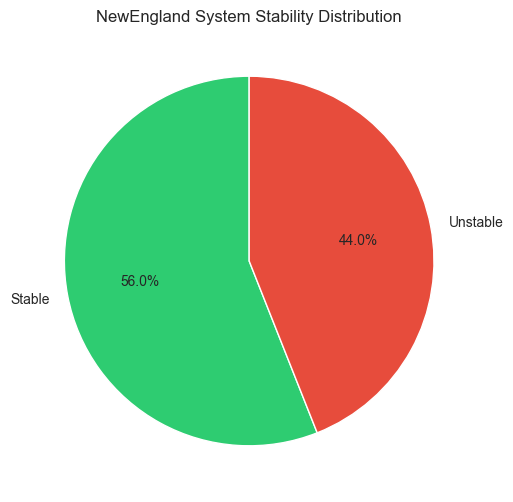

In [5]:
stats = results.get_statistics()

print(f"Grid: {stats['grid_name']}")
print(f"Total Events: {stats['total_events']}")
print(f"Stable: {stats['stable_events']} ({stats['stability_ratio']*100:.1f}%)")
print(f"Unstable: {stats['unstable_events']}")

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))
labels = ['Stable', 'Unstable']
sizes = [stats['stable_events'], stats['unstable_events']]
colors = ['#2ecc71', '#e74c3c']
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax.set_title(f"{stats['grid_name']} System Stability Distribution")
plt.show()

## 6. Generate Dataset

Convert simulation results to training dataset:

In [6]:
dataset, splits = generate_dataset_from_simulation(
    results,
    snapshot_type='clearing',  # Use 'fault' or 'clearing'
    test_size=0.2,
    val_size=0.2,
    random_state=42
)

print(f"\nDataset: {dataset}")
print(f"\nData splits:")
print(f"  Train: {splits['X_train'].shape[0]} samples")
print(f"  Test: {splits['X_test'].shape[0]} samples")
print(f"  Validation: {splits['X_val'].shape[0]} samples")


Dataset: StabilityDataset(grid='NewEngland', n_samples=100, n_features=78)

Data splits:
  Train: 64 samples
  Test: 20 samples
  Validation: 16 samples


## 7. Explore Data

Inspect the generated features:

In [7]:
# View DataFrame
train_df = splits['train']
print(f"Training data shape: {train_df.shape}")
print(f"\nFirst few columns:")
display(train_df.head())

# Label distribution
print(f"\nLabel distribution in training set:")
print(train_df['stable-unstable'].value_counts())

Training data shape: (64, 79)

First few columns:


,bus_1:u,bus_1:phi,bus_2:u,bus_2:phi,bus_3:u,bus_3:phi,bus_4:u,bus_4:phi,bus_5:u,bus_5:phi,...,bus_35:phi,bus_36:u,bus_36:phi,bus_37:u,bus_37:phi,bus_38:u,bus_38:phi,bus_39:u,bus_39:phi,stable-unstable
0,0.997555,3.161212,1.038691,-2.076599,0.982174,-3.723613,1.022563,-7.101873,1.027028,3.576716,...,4.543517,1.035514,8.574584,1.007239,-2.900512,1.021606,-12.955243,1.049866,2.310899,0
1,1.018349,5.792367,1.031203,-4.488154,1.026536,-2.881203,1.026842,4.951117,1.072824,-9.255831,...,-10.693958,1.006138,0.977620,1.069063,-10.736735,1.061470,0.076518,0.992806,3.455403,0
2,1.056024,-10.221006,1.007056,-5.872002,1.020145,-7.666986,1.004763,-8.871462,1.083766,0.261161,...,4.959583,1.031543,-6.960733,1.005278,-7.844516,1.021102,7.073767,0.992312,3.732959,0
3,1.064899,0.795417,1.007472,-2.627654,0.985232,-10.186422,1.032023,0.451307,0.976755,-7.971819,...,8.281694,1.050577,-3.146773,0.984930,-0.774278,1.012535,6.735264,0.967843,9.415102,0
4,0.770051,-42.287069,0.756312,-14.564291,1.000116,6.510072,0.934909,-49.203105,0.815664,29.465377,...,-17.091869,0.787201,-15.310976,0.712887,-10.240061,0.815125,-15.856588,0.972281,-29.630204,0



Label distribution in training set:
stable-unstable
0    34
1    30
Name: count, dtype: int64


## 8. Feature Statistics

Analyze feature distributions:

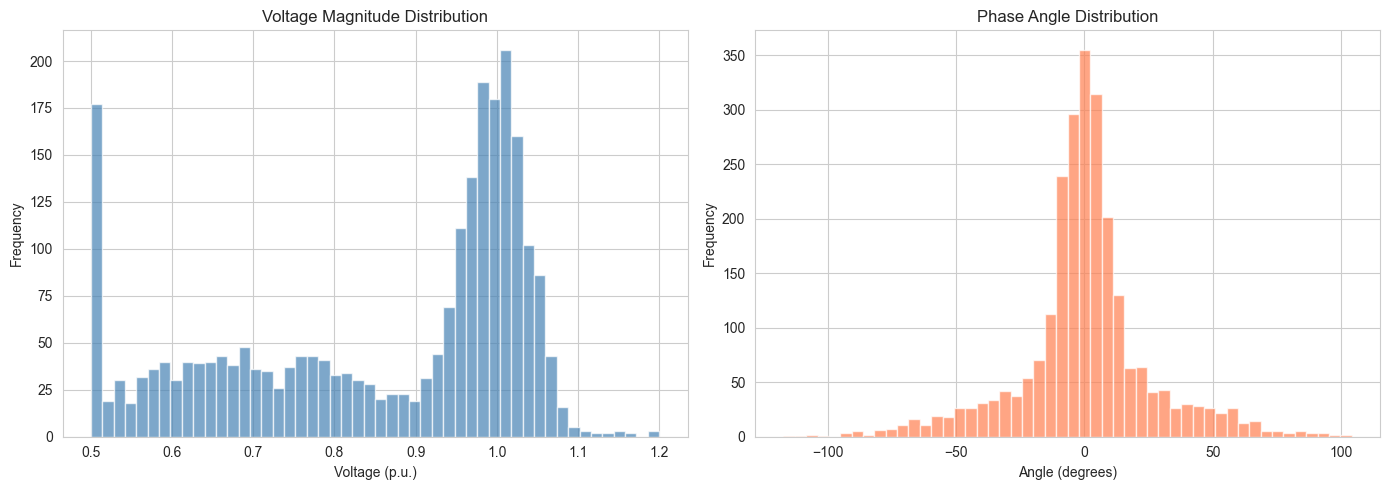

In [8]:
# Feature statistics
features = splits['X_train']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Voltage features (even indices)
voltage_features = features[:, ::2]
axes[0].hist(voltage_features.flatten(), bins=50, color='steelblue', alpha=0.7)
axes[0].set_title('Voltage Magnitude Distribution')
axes[0].set_xlabel('Voltage (p.u.)')
axes[0].set_ylabel('Frequency')

# Angle features (odd indices)
angle_features = features[:, 1::2]
axes[1].hist(angle_features.flatten(), bins=50, color='coral', alpha=0.7)
axes[1].set_title('Phase Angle Distribution')
axes[1].set_xlabel('Angle (degrees)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 9. Save Dataset

The dataset is automatically saved, but you can also export it:

In [9]:
# Dataset is already saved in:
# - simulation_results/data/NewEngland.pickle (legacy format)
# - simulation_results/NewEngland/pickles/NewEngland_results.pickle (new format)

print("✓ Dataset saved and ready for training!")
print("\nFiles generated:")
print("  - simulation_results/data/NewEngland.pickle")
print("  - simulation_results/NewEngland/pickles/NewEngland_results.pickle")

✓ Dataset saved and ready for training!

Files generated:
  - simulation_results/data/NewEngland.pickle
  - simulation_results/NewEngland/pickles/NewEngland_results.pickle
